# Sensitivity analysis

This notebook runs one-at-a-time sensitivity checks for key parameters and summarizes how $R_0$ and cumulative incidence change. For model details, see `tex/tb_background.tex`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.model import compute_basic_reproduction_number, run_simulation
from src.parameters import ModelParameters, create_default_initial_state
from src.plotting import plot_tornado

In [2]:
parameters = ModelParameters()
initial_state = create_default_initial_state(parameters)

start_year = 0.0
end_year = 100.0
time_points = np.linspace(start_year, end_year, 1001)

baseline_results = run_simulation(parameters, initial_state, (start_year, end_year), time_points)
baseline_r0 = compute_basic_reproduction_number(parameters)
baseline_cumulative_incidence = np.trapz(
    baseline_results["incident_active_tb"], baseline_results["time_years"]
)

print(f"Baseline R0: {baseline_r0:.2f}")
print(f"Baseline cumulative incidence: {baseline_cumulative_incidence:,.0f}")

Baseline R0: 1.34
Baseline cumulative incidence: 46,450


In [3]:
from dataclasses import asdict

parameter_names = [
    "transmission_rate",
    "fast_progressor_fraction",
    "fast_progression_rate",
    "slow_reactivation_rate",
    "treatment_rate",
    "self_cure_rate",
    "tb_mortality_rate",
    "relapse_rate_treated",
]

low_multiplier = 0.8
high_multiplier = 1.2

low_r0_values = []
high_r0_values = []
low_incidence_values = []
high_incidence_values = []

for parameter_name in parameter_names:
    base_values = asdict(parameters)
    low_value = base_values[parameter_name] * low_multiplier
    high_value = base_values[parameter_name] * high_multiplier

    low_parameters = ModelParameters(**{**base_values, parameter_name: low_value})
    high_parameters = ModelParameters(**{**base_values, parameter_name: high_value})

    low_initial_state = create_default_initial_state(low_parameters)
    high_initial_state = create_default_initial_state(high_parameters)

    low_results = run_simulation(
        low_parameters, low_initial_state, (start_year, end_year), time_points
    )
    high_results = run_simulation(
        high_parameters, high_initial_state, (start_year, end_year), time_points
    )

    low_r0_values.append(compute_basic_reproduction_number(low_parameters))
    high_r0_values.append(compute_basic_reproduction_number(high_parameters))

    low_incidence_values.append(
        np.trapz(low_results["incident_active_tb"], low_results["time_years"])
    )
    high_incidence_values.append(
        np.trapz(high_results["incident_active_tb"], high_results["time_years"])
    )

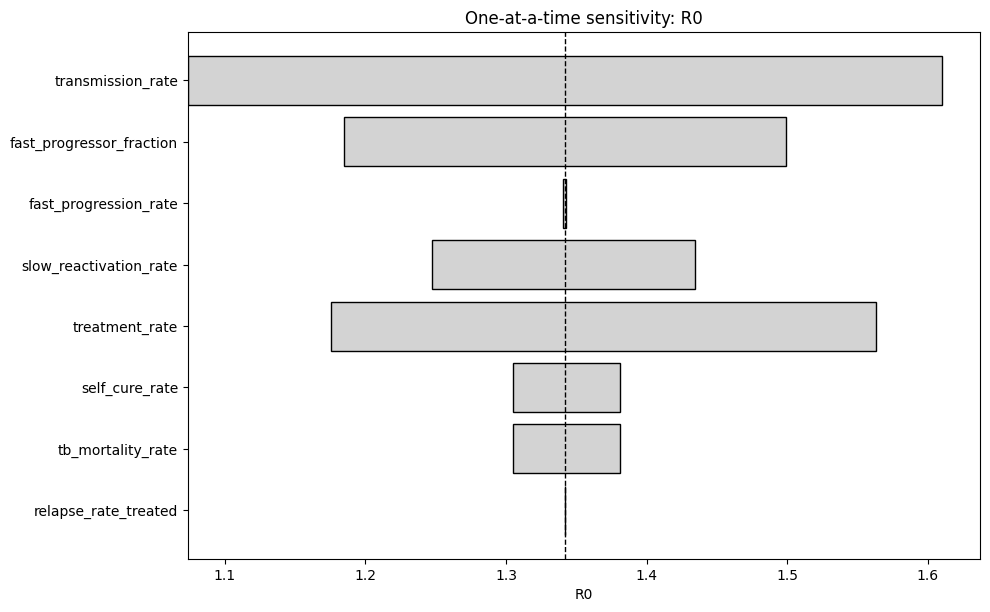

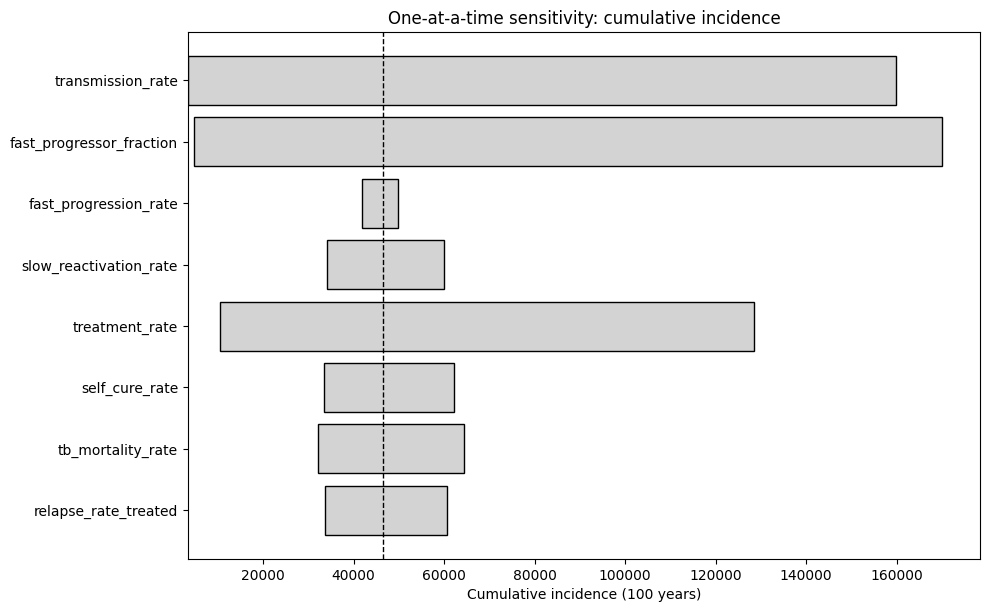

In [4]:
plot_tornado(
    parameter_names=parameter_names,
    low_values=np.array(low_r0_values),
    high_values=np.array(high_r0_values),
    baseline_value=baseline_r0,
    x_label="R0",
)
plt.title("One-at-a-time sensitivity: R0")
plt.show()

plot_tornado(
    parameter_names=parameter_names,
    low_values=np.array(low_incidence_values),
    high_values=np.array(high_incidence_values),
    baseline_value=baseline_cumulative_incidence,
    x_label="Cumulative incidence (100 years)",
)
plt.title("One-at-a-time sensitivity: cumulative incidence")
plt.show()